# Lab02: House Prices — Advanced Regression (PyTorch + CRISP-DM)

Cuộc thi Kaggle: dự báo `SalePrice` (RMSLE). Toàn bộ mô hình bằng PyTorch.
Nhật ký thí nghiệm: `experiments/model_log.md`.


## 0. Thiết lập & helpers (GĐ0)


In [16]:
# --- Thư viện chuẩn: mỗi dòng 1 lệnh import ---
import csv  # ghi thêm dòng vào runs.csv (dùng trong save_run)
import json  # lưu cấu hình thí nghiệm dạng JSON
import random  # gieo seed cho hàm ngẫu nhiên của python
from pathlib import Path  # thao tác đường dẫn gọn, chạy được mọi OS
import numpy as np  # tính toán số (trung bình, độ lệch chuẩn CV)
import pandas as pd  # đọc CSV và EDA
import torch  # xây + huấn luyện mọi mô hình (chỉ dùng CPU)
import matplotlib.pyplot as plt  # vẽ đường học, residual
import seaborn as sns  # vẽ biểu đồ thống kê đẹp hơn
from sklearn.model_selection import KFold  # chia K-fold CV

# --- Seed chung: giữ mỗi lần chạy cho kết quả giống nhau ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Đường dẫn: tự động nhận cả khi mở ở root hay trong Lab02 ---
ROOT = (
    Path("data") if Path("data").exists() else Path("Lab02/data")
)  # thư mục CSV Kaggle
EXP = (
    Path("experiments") if Path("experiments").exists() else Path("Lab02/experiments")
)  # thư mục log
print(torch.__version__, "| train/test sẽ đọc ở Part 1")

2.14.0+cpu | train/test sẽ đọc ở Part 1


In [17]:
"""Ham dung chung cho moi thi nghiem (M0-M7)."""


def make_exp_id(model, tag):
    """Ghép ID duy nhất cho thí nghiệm, vd: M5_mlp_d3_w128_do02."""
    return f"{model}_{tag}"


def rmsle(y_true_log, y_pred_log):
    """Tính RMSLE trực tiếp trên thang log (khớp metric Kaggle)."""
    return float(
        np.sqrt(np.mean((np.asarray(y_pred_log) - np.asarray(y_true_log)) ** 2))
    )


def save_run(exp_id, model, params, fold_scores, note="", decision=""):
    """Lưu 1 thí nghiệm vào 3 nơi: JSON cấu hình, runs.csv, model_log.md."""
    (EXP / "configs").mkdir(parents=True, exist_ok=True)  # tạo thư mục nếu chưa có
    (EXP / "configs" / f"{exp_id}.json").write_text(
        json.dumps(  # lưu cấu hình để tái lập
            {
                "exp_id": exp_id,
                "model": model,
                "params": params,
                "fold_scores": fold_scores,
            },
            indent=1,
        )
    )
    m, s = (
        float(np.mean(fold_scores)),
        float(np.std(fold_scores)),
    )  # trung bình ± lệch chuẩn CV
    row = {
        "exp_id": exp_id,
        "model": model,
        "params": json.dumps(params),
        "cv_mean": round(m, 5),
        "cv_std": round(s, 5),
        "fold_scores": str([round(float(x), 5) for x in fold_scores]),
        "note": note,
        "decision": decision,
    }
    with open(
        EXP / "runs.csv", "a", newline="", encoding="utf-8"
    ) as f:  # ghi thêm vào bảng máy đọc
        w = csv.DictWriter(f, fieldnames=list(row))
        w.writerow(row)
    with open(
        EXP / "model_log.md", "a", encoding="utf-8"
    ) as f:  # ghi thêm vào nhật ký người đọc
        f.write(
            f"| {exp_id} | {model} | `{row['params']}` | {row['cv_mean']} ± {row['cv_std']} | {note} | {decision} |\n"
        )
    print(f"[{exp_id}] CV-RMSLE = {m:.5f} ± {s:.5f} -> {decision}")


# --- Tự kiểm: RMSLE của dự đoán lệch nhẹ phải ~0.1 ---
print("helpers OK:", rmsle([11.0, 12.0], [11.1, 11.9]))

helpers OK: 0.09999999999999964


## 1. Business Understanding — Xác định bài toán (GĐ1)
*(phân tích chi tiết ở GĐ1)*


### 1.1. Mục tiêu (Business Understanding)
- **Bài toán:** hồi quy có giám sát — dự báo giá bán `SalePrice` (USD) của 1459 căn nhà ở Ames, Iowa trong tập test Kaggle.
- **Bối cảnh thực tế (paper De Cock):** thay mô hình định giá thủ công của Văn phòng Thẩm định Ames bằng mô hình học từ ~80 biến mô tả nhà.
- **Metric chấm điểm:** RMSLE — căn bậc hai sai số bình phương trên thang log: `sqrt(mean((log1p(pred)-log1p(true))^2))`.
  Hệ quả: phạt sai số *tương đối* (nhà rẻ sai 10k nặng hơn nhà đắt sai 10k), nên mọi huấn luyện/đánh giá đều làm trên thang log.
- **Dữ liệu:** train 1460 dòng (có nhãn) + test 1459 dòng; 79 biến giải thích: 23 nominal, 23 ordinal, 14 discrete, 20 continuous.
- **Tiêu chí thành công:** CV-RMSLE ổn định và giảm dần qua các thí nghiệm; tham chiếu paper (Neighborhood+TotalSF ≈ R² 80%); điểm public LB khi nộp Kaggle.
- **Ràng buộc:** toàn bộ mô hình bằng PyTorch (sklearn chỉ chia fold + tiền xử lý); đủ 6 bước CRISP-DM; có nhật ký thí nghiệm.


## 2. Data Understanding — EDA (GĐ1)
*(phân phối giá, missing, tương quan, outlier — GĐ1)*


In [18]:
# --- Đọc dữ liệu, xem kích thước và phân phối biến mục tiêu ---
train = pd.read_csv(ROOT / "train.csv")  # tập train: có cột SalePrice để học
test = pd.read_csv(ROOT / "test.csv")  # tập test: không nhãn, cần dự báo để nộp
print("train:", train.shape, "| test:", test.shape)  # kiểm tra đúng 1460/1459 dòng
y = train["SalePrice"]  # biến mục tiêu (USD)
print(
    y.describe()[["count", "mean", "std", "min", "50%", "max"]].round(1)
)  # thống kê mô tả nhanh
print(
    "skew giá gốc:",
    round(float(y.skew()), 3),
    "| skew sau log1p:",
    round(float(np.log1p(y).skew()), 3),
)

train: (1460, 81) | test: (1459, 80)
count      1460.0
mean     180921.2
std       79442.5
min       34900.0
50%      163000.0
max      755000.0
Name: SalePrice, dtype: float64
skew giá gốc: 1.883 | skew sau log1p: 0.121


In [19]:
# --- Đếm ô trống (missing) theo từng cột ---
miss = train.isna().sum()  # đếm số ô trống mỗi cột
miss = miss[miss > 0].sort_values(ascending=False)  # chỉ giữ cột có thiếu, xếp giảm dần
print(f"Co {len(miss)} cột thiếu / {train.shape[1]} cot")
print(
    (
        miss.to_frame("n_thiếu").assign(
            ty_le=lambda d: (d["n_thiếu"] / len(train)).round(3)
        )
    ).head(20)
)

Co 19 cột thiếu / 81 cot
              n_thiếu  ty_le
PoolQC           1453  0.995
MiscFeature      1406  0.963
Alley            1369  0.938
Fence            1179  0.808
MasVnrType        872  0.597
FireplaceQu       690  0.473
LotFrontage       259  0.177
GarageType         81  0.055
GarageYrBlt        81  0.055
GarageFinish       81  0.055
GarageQual         81  0.055
GarageCond         81  0.055
BsmtExposure       38  0.026
BsmtFinType2       38  0.026
BsmtQual           37  0.025
BsmtCond           37  0.025
BsmtFinType1       37  0.025
MasVnrArea          8  0.005
Electrical          1  0.001


In [20]:
# --- Tương quan biến số với giá + độ phong phú biến phân loại + outlier ---
num = train.select_dtypes(include=[np.number]).drop(
    columns=["Id", "SalePrice"]
)  # chỉ biến số
corr = num.corrwith(np.log1p(y)).sort_values(
    ascending=False
)  # tương quan với log-giá (khớp metric)
print("Top tương quan dương:")
print(corr.head(8).round(3))
print("Top tương quan âm:")
print(corr.tail(3).round(3))
cat = train.select_dtypes(exclude=[np.number]).columns  # các cột phân loại (chuỗi)
print("Số cột phân loại:", len(cat), "| nhiều mức nhất:")
print(train[cat].nunique().sort_values(ascending=False).head(8))  # đếm số mức mỗi cột
out = train[train["GrLivArea"] > 4000][
    ["GrLivArea", "SalePrice"]
]  # outlier paper đã cảnh báo
print(f"Số nhà GrLivArea>4000: {len(out)}")
print(out.to_string())

Top tương quan dương:
OverallQual    0.817
GrLivArea      0.701
GarageCars     0.681
GarageArea     0.651
TotalBsmtSF    0.612
1stFlrSF       0.597
FullBath       0.595
YearBuilt      0.587
dtype: float64
Top tương quan âm:
MSSubClass      -0.074
KitchenAbvGr    -0.148
EnclosedPorch   -0.149
dtype: float64
Số cột phân loại: 43 | nhiều mức nhất:
Neighborhood    25
Exterior2nd     16
Exterior1st     15
Condition1       9
SaleType         9
HouseStyle       8
RoofMatl         8
Condition2       8
dtype: int64
Số nhà GrLivArea>4000: 4
      GrLivArea  SalePrice
523        4676     184750
691        4316     755000
1182       4476     745000
1298       5642     160000


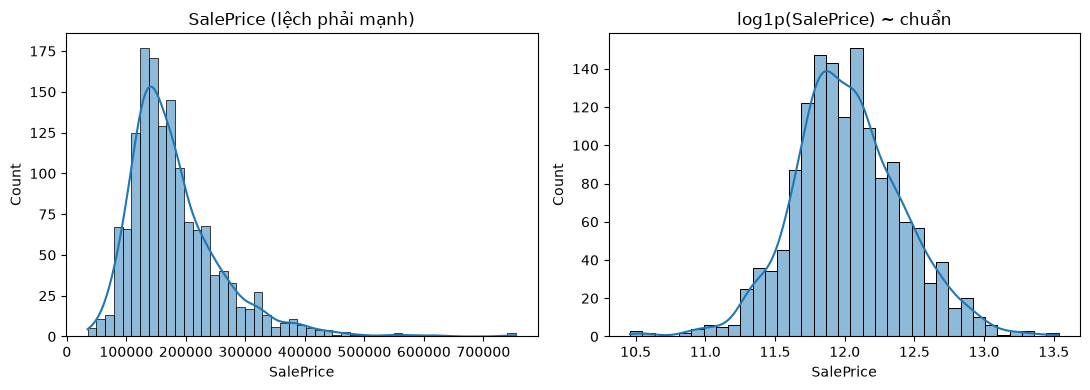

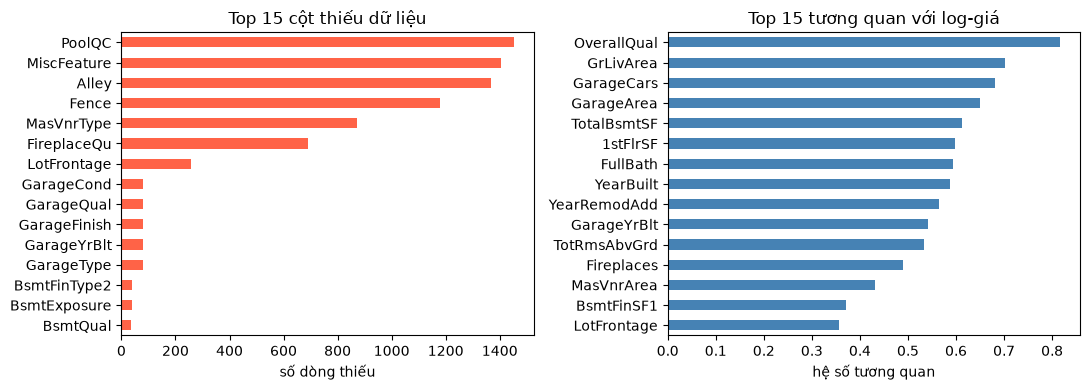

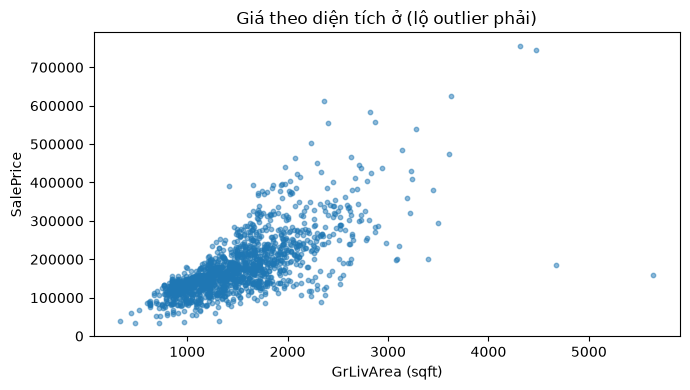

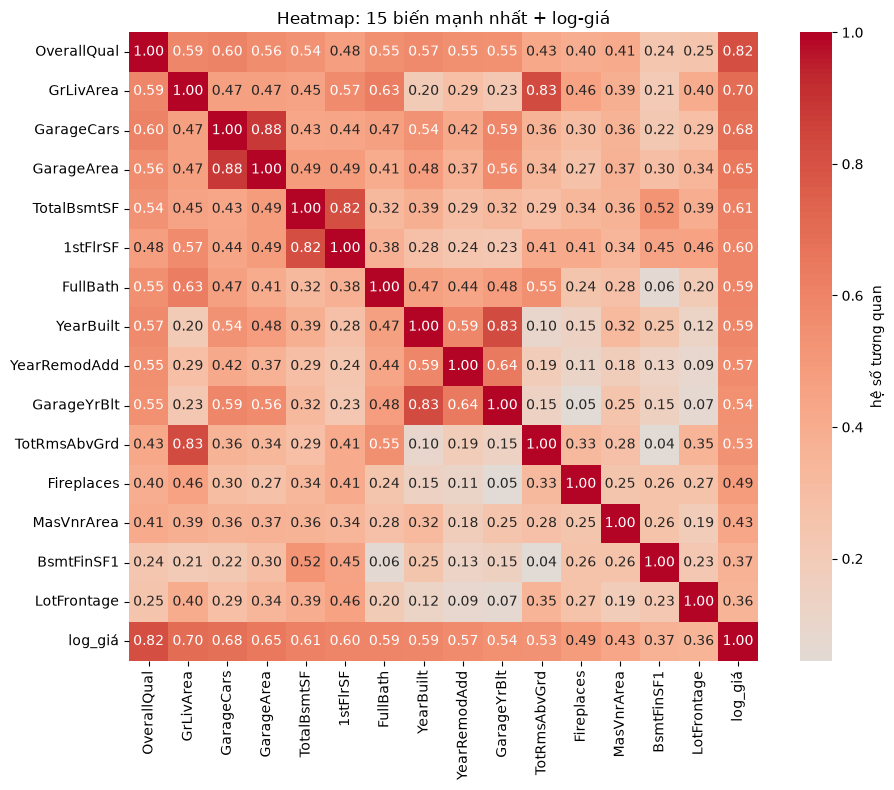

Đã lưu ảnh vào experiments\figures


In [21]:
# --- Vẽ 4 biểu đồ EDA, vừa hiển thị vừa lưu cho báo cáo ---
FIG = EXP / "figures"
FIG.mkdir(parents=True, exist_ok=True)  # thư mục chứa ảnh (không commit)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))  # 2 ô cạnh nhau: giá gốc vs log-giá
sns.histplot(y, kde=True, ax=ax[0])
ax[0].set_title("SalePrice (lệch phải mạnh)")  # đuôi dài bên phải
sns.histplot(np.log1p(y), kde=True, ax=ax[1])
ax[1].set_title("log1p(SalePrice) ~ chuẩn")  # đối xứng hơn
fig.tight_layout()
fig.savefig(FIG / "eda_gia.png", dpi=100)
plt.show()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
miss.head(15).sort_values().plot.barh(
    ax=ax[0], color="tomato"
)  # 15 cột thiếu nhiều nhất
ax[0].set_title("Top 15 cột thiếu dữ liệu")
ax[0].set_xlabel("số dòng thiếu")
corr.head(15).sort_values().plot.barh(
    ax=ax[1], color="steelblue"
)  # 15 biến số liên quan nhất
ax[1].set_title("Top 15 tương quan với log-giá")
ax[1].set_xlabel("hệ số tương quan")
fig.tight_layout()
fig.savefig(FIG / "eda_missing_corr.png", dpi=100)
plt.show()
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(train["GrLivArea"], y, s=10, alpha=0.5)  # mỗi chấm là 1 căn nhà
ax.set_xlabel("GrLivArea (sqft)")
ax.set_ylabel("SalePrice")
ax.set_title("Giá theo diện tích ở (lộ outlier phải)")
fig.tight_layout()
fig.savefig(FIG / "eda_outlier.png", dpi=100)
plt.show()
# --- Heatmap: nhìn 1 ảnh thấy ngay cụm biến nào đi cùng nhau ---
top15 = corr.head(15).index.tolist()  # 15 biến số liên quan nhất toi gia
sub = train[top15].copy()
sub["log_giá"] = np.log1p(y)  # thêm cột log-giá để đối chiếu
C = sub.corr()  # ma trận tương quan đôi một
fig, ax = plt.subplots(figsize=(10, 8))  # ô vuông để dễ đọc
sns.heatmap(
    C,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,  # số trên từng ô, đỏ=xanh theo dấu
    cbar_kws={"label": "hệ số tương quan"},
    ax=ax,
)
ax.set_title(
    "Heatmap: 15 biến mạnh nhất + log-giá"
)  # cụm Garage/DT nằm sát nhau = đa cộng tuyến
fig.tight_layout()
fig.savefig(FIG / "eda_corr_heatmap.png", dpi=100)
plt.show()
print("Đã lưu ảnh vào", FIG)

### 2.1. Nhận xét EDA

- **Giá lệch phải mạnh:** skew 1.883, trung vị 163k < trung bình 181k; sau `log1p` skew còn 0.121 (~chuẩn) → quyết định làm việc trên thang log là đúng, khớp metric RMSLE.
- **Thiếu dữ liệu 19/81 cột, đều có ý nghĩa:** PoolQC (99.5%), MiscFeature (96%), Alley (94%), Fence (81%) thiếu = *không có* hạng mục đó → điền `'Missing'` thay vì xóa. Nhóm garage (5.5%) và basement (~2.5%) thiếu đồng loạt theo cụm → cùng cách xử lý. Chỉ MasVnrArea (8) và Electrical (1) là thiếu lẻ.
- **Biến số đắt giá nhất:** OverallQual (0.817), GrLivArea (0.701), GarageCars (0.681), GarageArea (0.651), TotalBsmtSF (0.612) — đúng các biến paper nhấn mạnh. Tương quan âm nhẹ: EnclosedPorch (-0.149), KitchenAbvGr (-0.148) — bếp/hiên phụ nhiều đôi khi đi với nhà cũ nhỏ.
- **Biến phân loại:** 43 cột; Neighborhood nhiều mức nhất (25 mức trong train) → one-hot phình chiều nhưng cần thiết (hiệu ứng vị trí mạnh theo paper).
- **Outlier:** 4 căn GrLivArea > 4000 (paper báo 5 trên toàn bộ 2930 dòng; tập train Kaggle có 4), gồm 2 căn to nhưng rẻ bất thường (dòng 523: 4676 sqft giá 184750; dòng 1298: 5642 sqft giá 160000) → loại khỏi train theo khuyến nghị.
- **Nhìn heatmap:** cụm Garage (Cars/Area), cụm diện tích (GrLivArea/TotalBsmtSF/1stFlrSF) và OverallQual dính chùm đỏ → đa cộng tuyến rõ, báo trước GĐ2 phải dùng regularization.


## 3. Data Preparation — Pipeline + K-fold (GĐ1)
*(tiền xử lý dùng chung, cố định seed — GĐ1)*


### 3.1. Quyết định tiền xử lý (dùng chung cho mọi mô hình)
- **Target:** `y_log = log1p(SalePrice)` — khớp metric RMSLE, giảm lệch và phương sai tăng theo giá.
- **Số:** median-impute (bền với outlier) → `log1p` các cột lệch mạnh (skew > 0.75, học từ train) → chuẩn hóa z-score.
- **Phân loại:** điền `'Missing'` (vì thiếu ở đây *có ý nghĩa*: không có garage/hầm...) → one-hot (bỏ qua mức lạ ở test).
- **Outlier:** loại các căn `GrLivArea > 4000` khỏi train theo khuyến nghị của paper (test giữ nguyên để dự báo đủ 1459 dòng).
- **Validation:** K-fold 5 phần, shuffle, seed 42 — mọi mô hình dùng chung 1 bộ fold (lưu `experiments/processed/folds.json`).
- Mảng đã xử lý lưu vào `experiments/processed/` để GĐ2 nạp lại nhanh, khỏi chạy lại pipeline.


In [22]:
# --- Pipeline tiền xử lý dùng chung: fit trên train, áp cho cả test ---
from sklearn.compose import ColumnTransformer  # ghép nhiều bước xử lý theo nhóm cột
from sklearn.pipeline import Pipeline  # chuỗi bước xử lý biến số / phân loại
from sklearn.impute import SimpleImputer  # điền ô trống
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # mã hóa + chuẩn hóa
from sklearn.base import (
    BaseEstimator,
    TransformerMixin,
)  # lớp tự viết log1p cho cột lệch


class Log1pSkewed(BaseEstimator, TransformerMixin):
    """Log1p các cột số bị lệch mạnh (học ngưỡng skew từ train)."""

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)  # đảm bảo dạng số để tính skew
        self.cols_ = [
            j
            for j in range(X.shape[1])  # giữ chỉ số các cột có skew > 0.75
            if float(pd.Series(X[:, j]).skew()) > 0.75
        ]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()  # copy để không sửa dữ liệu gốc
        X[:, self.cols_] = np.log1p(
            np.clip(X[:, self.cols_], 0, None)
        )  # log1p, chặn âm về 0
        return X


tr = train[train["GrLivArea"] <= 4000].reset_index(
    drop=True
)  # bỏ outlier GrLivArea>4000 theo paper
print(f"Bỏ {len(train) - len(tr)} outlier -> train còn {len(tr)} dòng")
y_log = np.log1p(tr["SalePrice"].to_numpy(dtype=float))  # target trên thang log
feat = [c for c in tr.columns if c not in ("Id", "SalePrice")]  # 79 cột đặc trưng
num_cols = tr[feat].select_dtypes(include=[np.number]).columns.tolist()  # nhóm cột số
cat_cols = [c for c in feat if c not in num_cols]  # phần còn lại là phân loại
print(f"Số: {len(num_cols)} | Phân loại: {len(cat_cols)}")
pre = ColumnTransformer(
    [  # mỗi nhóm cột 1 pipeline riêng
        (
            "so",
            Pipeline(
                [
                    (
                        "dien",
                        SimpleImputer(strategy="median"),
                    ),  # điền trung vị, bền với outlier
                    ("loglech", Log1pSkewed()),  # log1p cột lệch
                    ("chuan", StandardScaler()),
                ]
            ),  # đưa về trung bình 0, phương sai 1
            num_cols,
        ),
        (
            "loai",
            Pipeline(
                [
                    (
                        "dien",
                        SimpleImputer(strategy="constant", fill_value="Missing"),
                    ),  # thiếu = không có
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),  # mã hóa nhị phân
            cat_cols,
        ),
    ]
)
Xtr = pre.fit_transform(tr[feat]).astype(np.float32)  # FIT trên train
Xte = pre.transform(test[feat]).astype(np.float32)  # chỉ TRANSFORM test (tránh rò rỉ)
print("X_train:", Xtr.shape, "| X_test:", Xte.shape)  # xem số chiều sau one-hot
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)  # 5 fold chung cho mọi mô hình
folds = [
    (tr_idx.tolist(), va_idx.tolist()) for tr_idx, va_idx in kf.split(Xtr)
]  # chỉ số từng fold
OUT = EXP / "processed"
OUT.mkdir(parents=True, exist_ok=True)  # thư mục chứa mảng xử lý (không commit)
np.save(OUT / "X_train.npy", Xtr)
np.save(OUT / "X_test.npy", Xte)
np.save(OUT / "y_log.npy", y_log)
(OUT / "folds.json").write_text(json.dumps(folds))  # lưu fold để GĐ2 dùng lại y hệt
print("Đã lưu mảng + folds vào", OUT)

Bỏ 4 outlier -> train còn 1456 dòng
Số: 36 | Phân loại: 43
X_train: (1456, 302) | X_test: (1459, 302)
Đã lưu mảng + folds vào experiments\processed


### 3.2. Nhận xét pipeline

- Loại 4 outlier → train còn **1456 dòng**; 36 cột số + 43 cột phân loại → sau one-hot thành **302 đặc trưng** (test cùng 302 chiều nhờ `handle_unknown='ignore'`).
- Fit chỉ trên train, transform test → không rò rỉ; 5 fold chung lưu ở `experiments/processed/folds.json`, mảng lưu `.npy` để GĐ2 nạp lại nhanh.
- Rủi ro đã biết: one-hot 302 chiều trên 1456 dòng dễ overfit với OLS → GĐ2 cần Ridge/Lasso/Dropout trị; biến ordinal đang one-hot chung, có thể nâng cấp mapping thứ tự nếu CV chưa tốt.


## 4. Modeling M0–M7 + fine-tune (GĐ2)
*(mỗi mô hình: screening → refine 5-fold → refit; log đầy đủ — GĐ2)*


## 5. Evaluation (GĐ3)
*(so sánh, residual, chốt mô hình — GĐ3)*


## 6. Deployment (GĐ3)
*(submission.csv + nộp Kaggle — GĐ3)*
